# UCS420 Lab Assignment 9 — NLP Text Preprocessing
Enter your roll number and name, then run all cells.

In [1]:
ROLL_NO = 1024160136          # <-- your full roll number
NAME = "Pridhi Thareja"            # <-- your name

import nltk
for pkg in ["punkt", "punkt_tab", "stopwords", "wordnet", "omw-1.4",
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(pkg, quiet=True)
assert ROLL_NO > 0 and NAME, "Enter your roll number and name first"

### Dataset generator — do not modify

In [2]:
import random, hashlib
import pandas as pd

def generate_dataset(roll_no):
    """Return (DataFrame of tickets, focus ticket IDs, fingerprint) for a roll number. Do not modify."""
    rng = random.Random(int(roll_no))

    subjects = [("LMS", ["LMS", "lms"]), ("Wi-Fi", ["Wi-Fi", "WiFi", "wifi"]), ("VPN", ["VPN"]),
                ("email", ["email", "e-mail"]), ("password", ["password"]), ("portal", ["student portal"]),
                ("projector", ["projector"]), ("laptop", ["laptop"]), ("MATLAB", ["MATLAB", "Matlab"]),
                ("Python", ["Python"]), ("printer", ["printer"]), ("server", ["server"])]
    actions = ["is not working", "keeps disconnecting", "failed to open", "is running slowly",
               "crashes while opening", "stopped responding", "is showing an error", "was working yesterday",
               "has stopped syncing", "keeps asking for login"]
    user_actions = ["cannot access", "can't open", "couldn't connect to", "am unable to use",
                    "tried restarting", "was locked out of", "keep getting logged out of", "reinstalled"]
    contexts = ["after resetting my password", "during the lab", "on my laptop", "since yesterday",
                "after the latest update", "when I use mobile hotspot", "before the assignment deadline",
                "while uploading the file", "after restarting the system", "when connected to campus Wi-Fi"]
    endings = ["Please help.", "Can you check this?", "I have tried several times!", "It worked yesterday.",
               "I don't know what changed.", "The same problem occurs again.", "Is there another solution?",
               "It works on another computer.", "This is urgent.", "Please resolve it."]
    challenges = {
        "negation": ["The Wi-Fi works, but the VPN doesn't.", "Why isn't the portal opening?",
                     "I can't login and I didn't change anything.", "It's not the laptop; it's the server.",
                     "Nothing works and nobody has replied.", "The printer won't print; it isn't jammed."],
        "numbers": ["Python 3.12 was installed yesterday.", "The file is 95.5% uploaded.",
                    "Error code 0x80070005 appears.", "I need Windows 11 by 5.30 p.m. today.",
                    "Only 2 of 30 PCs boot after 3.5 hours.", "Version 2.0.1 crashes at 99%."],
        "identifiers": ["Email me at helpdesk@university.edu.", "See https://lms.thapar.edu/help for details.",
                        "My roll no. is 1023-03-021.", "Ticket #4521 is still open.",
                        "Call me on +91 98765 43210 or 0175-239-3201.",
                        "Write to it.helpdesk@thapar.edu or visit www.thapar.edu/it."],
        "punctuation": ["I tried again... still no response!!!", "The LMS says 'Not Submitted'.",
                        "Dr. Rao's lab PC (No. 14) is down.", "Is it fixed?? Pls reply ASAP :(",
                        "The state-of-the-art lab (Lab-3) is closed.", "Re-installing didn't help; log-in still fails!"],
    }

    tickets = []
    for _ in range(8 + int(roll_no) % 5):
        _, variants = rng.choice(subjects)
        s = rng.choice(variants)
        template = rng.randrange(3)
        if template == 0:
            text = f"{s} {rng.choice(actions)} {rng.choice(contexts)}. {rng.choice(endings)}"
        elif template == 1:
            text = f"I {rng.choice(user_actions)} the {s} {rng.choice(contexts)}. {rng.choice(endings)}"
        else:
            text = f"The {s} {rng.choice(actions)}. {rng.choice(endings)}"
        tickets.append(text[0].upper() + text[1:])
    for category in ["negation", "numbers", "identifiers", "punctuation"]:
        tickets.append(rng.choice(challenges[category]))
    rng.shuffle(tickets)

    df = pd.DataFrame({"Ticket_ID": [f"T{i + 1:02d}" for i in range(len(tickets))], "Ticket_Text": tickets})
    focus = [f"T{i:02d}" for i in sorted(rng.sample(range(1, len(tickets) + 1), 2))]
    fingerprint = hashlib.md5(("|".join(tickets) + str(int(roll_no))).encode()).hexdigest()[:8].upper()
    return df, focus, fingerprint

### Preprocessing pipeline — do not modify

In [3]:
import string
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

STOP = set(stopwords.words("english"))

def is_punct(token):
    """A token is punctuation if EVERY character in it is in string.punctuation (e.g. '.', '...', '``', "''")."""
    return all(ch in string.punctuation for ch in token)

def process_ticket(text):
    """The official pipeline. Returns sentences, lowercase tokens, punctuation, stopwords and final tokens."""
    sentences = sent_tokenize(text)
    tokens = [t.lower() for s in sentences for t in word_tokenize(s)]
    punct = [t for t in tokens if is_punct(t)]
    stops = [t for t in tokens if t in STOP]
    final = [t for t in tokens if not is_punct(t) and t not in STOP]
    return {"sentences": sentences, "tokens": tokens, "punct": punct, "stops": stops, "final": final}

In [4]:
df, FOCUS, FINGERPRINT = generate_dataset(ROLL_NO)
print(f"Roll number: {ROLL_NO}   Name: {NAME}   Fingerprint: {FINGERPRINT}   Tickets: {len(df)}\n")
print(df.to_string(index=False))
df.to_csv(f"{ROLL_NO}_generated_dataset.csv", index=False)

Roll number: 1024160136   Name: Pridhi Thareja   Fingerprint: 852CB07E   Tickets: 13

Ticket_ID                                                                         Ticket_Text
      T01          I am unable to use the server after restarting the system. This is urgent.
      T02                                                      Error code 0x80070005 appears.
      T03                                               It's not the laptop; it's the server.
      T04 Projector has stopped syncing when I use mobile hotspot. I don't know what changed.
      T05                 Laptop keeps asking for login after the latest update. Please help.
      T06                          The MATLAB stopped responding. I have tried several times!
      T07               MATLAB failed to open when I use mobile hotspot. It worked yesterday.
      T08                      The student portal crashes while opening. It worked yesterday.
      T09          Password has stopped syncing when I use mobile ho

---
## Q1. Preprocessing pipeline
Run process_ticket() on every ticket and show one table with, per ticket: sentences, tokens, punctuation tokens, stopwords, unique tokens and final tokens, plus a TOTAL row.

In [5]:
import pandas as pd
proc, rows = {}, []
for tid, txt in zip(df.Ticket_ID, df.Ticket_Text):
    r = process_ticket(txt); proc[tid] = r
    rows.append({"Ticket_ID": tid, "Sentences": len(r["sentences"]), "Tokens": len(r["tokens"]),
                 "Punct": len(r["punct"]), "Stopwords": len(r["stops"]),
                 "Unique tokens": len(set(r["tokens"])), "Final tokens": len(r["final"])})
t1 = pd.DataFrame(rows)
t1.loc[len(t1)] = ["TOTAL"] + t1.drop(columns="Ticket_ID").sum().tolist()
display(t1)

for sel in FOCUS:
    r = proc[sel]
    print("Ticket:", sel, "|", df.set_index("Ticket_ID").Ticket_Text[sel])
    for k in ["tokens", "punct", "stops", "final"]:
        print(f"{k}:", r[k])
    print()

,Ticket_ID,Sentences,Tokens,Punct,Stopwords,Unique tokens,Final tokens
0,T01,2,16,2,8,14,6
1,T02,1,5,1,0,5,4
2,T03,1,11,2,5,8,4
3,T04,2,17,2,6,15,9
4,T05,2,13,2,3,12,8
5,T06,2,11,2,3,11,6
6,T07,2,14,2,4,13,8
7,T08,2,11,2,3,10,6
8,T09,2,14,2,4,13,8
9,T10,2,12,2,5,11,5


Ticket: T02 | Error code 0x80070005 appears.
tokens: ['error', 'code', '0x80070005', 'appears', '.']
punct: ['.']
stops: []
final: ['error', 'code', '0x80070005', 'appears']

Ticket: T04 | Projector has stopped syncing when I use mobile hotspot. I don't know what changed.
tokens: ['projector', 'has', 'stopped', 'syncing', 'when', 'i', 'use', 'mobile', 'hotspot', '.', 'i', 'do', "n't", 'know', 'what', 'changed', '.']
punct: ['.', '.']
stops: ['has', 'when', 'i', 'i', 'do', 'what']
final: ['projector', 'stopped', 'syncing', 'use', 'mobile', 'hotspot', "n't", 'know', 'changed']



**Observe:** Which final tokens in your data are not real words (e.g. n't, 's, ca)? Where do they come from?

Your answer:Several final tokens are not real words. n't (T04, from "don't") comes from word_tokenize, which splits contractions into a base word plus a clitic: do + n't. do is a stopword and is removed, but n't is not in NLTK's stopword list, so it survives as a final token. The same thing happens with 's (from "It's" in T03, appearing twice), where It + 's are split and it is removed as a stopword while 's stays. Both are fragments of contractions rather than words, and n't carries the negation meaning, so dropping it would change what the ticket says. Another non-word is 0x80070005 (T02), which is a hex error code rather than an English word, but it's kept intact as one token.

---
## Q2. Regular expressions
On your raw tickets, use re.findall to extract: words longer than 5 letters; all numbers (keep 95.5 and 2.0.1 whole); capitalized words; words starting with a vowel. Then use re.sub to replace emails with <EMAIL>, URLs with <URL> and phone numbers with <PHONE>. Your patterns must also work on TEST_LINES (given in the notebook).

In [6]:
TEST_LINES = [
    "Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.",
    "Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.",
    "The state-of-the-art lab isn't open; log-in at 5.30 p.m. didn't work.",
]

import re
from nltk.tokenize import sent_tokenize

raw = df.Ticket_Text.tolist()

# ---------- identifier patterns (used for re.sub, and to clean text before word patterns) ----------
EMAIL = r"[\w.+-]+@[\w-]+(?:\.[\w-]+)+"
URL   = r"(?:https?://|www\.)[\w\-./?=&%#~+:]*[\w/]"
PHONE = r"(?:\+\d{1,3}[\s-]?)?\b\d{5}[\s-]?\d{5}\b|\b0\d{2,4}-\d{3}-\d{4}\b"

def strip_ids(t):
    return re.sub("|".join([EMAIL, URL, PHONE]), " ", t)

clean_raw = [strip_ids(t) for t in raw]
clean_test = [strip_ids(t) for t in TEST_LINES]

# ---------- re.findall ----------
patterns = {
    "words > 5 letters": r"\b[A-Za-z]{6,}\b",
    "numbers (hex, 95.5, 2.0.1, 1,250 whole)": r"\b0[xX][0-9A-Fa-f]+\b|\b\d+(?:[.,]\d+)*\b",
    "capitalized words": r"\b[A-Z][a-z]+\b",
    "starts with vowel": r"(?<![\w'-])[aeiouAEIOU][A-Za-z]*(?:['-][A-Za-z]+)*",
}
for name, p in patterns.items():
    print(f"\n== {name} ==")
    for l in clean_test:
        print("  TEST   :", re.findall(p, l))
    found = [m for t in clean_raw for m in re.findall(p, t)]
    print(f"  TICKETS: {len(found)} matches, {len(set(found))} unique")
    print("  all    :", sorted(set(found)))

# ---------- re.sub ----------
def mask(t):
    t = re.sub(EMAIL, "<EMAIL>", t)
    t = re.sub(URL, "<URL>", t)
    return re.sub(PHONE, "<PHONE>", t)

print("\n== re.sub on TEST_LINES ==")
for l in TEST_LINES:
    print(mask(l))

print("\n== re.sub on tickets (only ones that changed) ==")
for tid, t in zip(df.Ticket_ID, raw):
    if mask(t) != t:
        print(tid, "BEFORE:", t); print(tid, "AFTER :", mask(t), "\n")

# ---------- Observe: capitalized only because sentence-initial ----------
start_caps, mid_caps = [], []
for t in raw:
    for s in sent_tokenize(t):
        first = re.match(r"\W*", s).end()
        for m in re.finditer(r"\b[A-Z][a-z]+\b", s):
            (start_caps if m.start() == first else mid_caps).append(m.group())

mid_set = set(mid_caps)
only_start = [w for w in start_caps if w not in mid_set]
print("\nCapitalized words total       :", len(start_caps) + len(mid_caps))
print("Sentence-initial              :", len(start_caps))
print("Mid-sentence                  :", len(mid_caps), sorted(mid_set))
print("Capitalized ONLY due to start :", len(only_start))
print(sorted(set(only_start)))


== words > 5 letters ==
  TEST   : []
  TEST   : ['Version']
  TEST   : []
  TICKETS: 53 matches, 36 unique
  all    : ['Laptop', 'MATLAB', 'Password', 'Please', 'Projector', 'another', 'appears', 'asking', 'changed', 'closed', 'crashes', 'failed', 'hotspot', 'laptop', 'latest', 'locked', 'mobile', 'opening', 'portal', 'printer', 'resolve', 'responding', 'restarting', 'server', 'several', 'showing', 'solution', 'stopped', 'student', 'syncing', 'system', 'unable', 'update', 'urgent', 'worked', 'yesterday']

== numbers (hex, 95.5, 2.0.1, 1,250 whole) ==
  TEST   : []
  TEST   : ['2.0.1', '95.5', '1,250']
  TEST   : ['5.30']
  TICKETS: 2 matches, 2 unique
  all    : ['0x80070005', '3']

== capitalized words ==
  TEST   : ['Mail']
  TEST   : ['Call', 'Version', 'Rs']
  TEST   : ['The']
  TICKETS: 18 matches, 11 unique
  all    : ['Email', 'Error', 'Is', 'It', 'Lab', 'Laptop', 'Password', 'Please', 'Projector', 'The', 'This']

== starts with vowel ==
  TEST   : ['or', 'or']
  TEST   : ['or



```
# This is formatted as code
```

**Observe:** How many of your capitalized words are capitalized only because they start a sentence?

Your answer:Out of 18 capitalized words in my tickets, 17 are capitalized only because they begin a sentence (Email, Error, Is, It, Laptop, Password, Please, Projector, The, This). Only one, Lab (from "Lab-3" in T13), is capitalized mid-sentence, and it is part of an identifier rather than a true proper noun. So almost every capitalized match is a sentence-start artifact, not a name. The pattern also misses all-caps words like MATLAB and the pronoun I, since it requires lowercase letters after the capital.

---
## Q3. Custom tokenizer
Write my_tokenize(text) with one RegexpTokenizer pattern that keeps contractions (isn't), hyphenated words (Wi-Fi, state-of-the-art), decimals and versions (95.5, 2.0.1), emails, URLs and phone numbers as single tokens. Run it on TEST_LINES and on your tickets, and compare with word_tokenize.

In [7]:
import re
from nltk.tokenize import RegexpTokenizer, word_tokenize

PATTERN = r"""
   [\w.+-]+@[\w-]+(?:\.[\w-]+)+                  # email
 | (?:https?://|www\.)[\w\-./?=&%#~+:]*[\w/]     # URL
 | (?:\+\d{1,3}[\s-]?)?\b\d{5}[\s-]?\d{5}\b
 | \b0\d{2,4}-\d{3}-\d{4}\b                      # phone
 | 0[xX][0-9A-Fa-f]+                             # hex codes
 | (?:[A-Za-z]\.){2,}                            # abbreviations like p.m.
 | \d+(?:[.,]\d+)*%?                             # integers, decimals, versions
 | \w+(?:[-']\w+)*                               # words, hyphenated, contractions
 | [^\w\s]                                       # punctuation
"""
_tok = RegexpTokenizer(PATTERN, flags=re.VERBOSE | re.UNICODE)
def my_tokenize(text): return _tok.tokenize(text)

for l in TEST_LINES:
    a, b = my_tokenize(l), word_tokenize(l)
    print("\nLINE:", l); print("mine :", a); print("nltk :", b)
    print("only mine:", [t for t in a if t not in b]); print("only nltk:", [t for t in b if t not in a])

print("\n--- ALL TICKETS ---")
diff_ids = []
for tid, t in zip(df.Ticket_ID, raw):
    a, b = my_tokenize(t), word_tokenize(t)
    if a != b:
        diff_ids.append(tid)
        print(tid, "| only mine:", [x for x in a if x not in b], "| only nltk:", [x for x in b if x not in a])
print(f"\n{len(diff_ids)} of {len(raw)} tickets are tokenized differently:", diff_ids)


LINE: Mail it.helpdesk@thapar.edu or a.b-c@dept.univ.ac.in; visit https://lms.thapar.edu/help or www.thapar.edu/it.
mine : ['Mail', 'it.helpdesk@thapar.edu', 'or', 'a.b-c@dept.univ.ac.in', ';', 'visit', 'https://lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
nltk : ['Mail', 'it.helpdesk', '@', 'thapar.edu', 'or', 'a.b-c', '@', 'dept.univ.ac.in', ';', 'visit', 'https', ':', '//lms.thapar.edu/help', 'or', 'www.thapar.edu/it', '.']
only mine: ['it.helpdesk@thapar.edu', 'a.b-c@dept.univ.ac.in', 'https://lms.thapar.edu/help']
only nltk: ['it.helpdesk', '@', 'thapar.edu', 'a.b-c', '@', 'dept.univ.ac.in', 'https', ':', '//lms.thapar.edu/help']

LINE: Call +91 98765 43210, +91-98765-43210 or 0175-239-3201. Version 2.0.1 is 95.5% done; fee Rs 1,250.
mine : ['Call', '+91 98765 43210', ',', '+91-98765-43210', 'or', '0175-239-3201', '.', 'Version', '2.0.1', 'is', '95.5%', 'done', ';', 'fee', 'Rs', '1,250', '.']
nltk : ['Call', '+91', '98765', '43210', ',', '+91-98765-43210', 'or', '0175-23

**Observe:** How many of your tickets are tokenized differently by my_tokenize and word_tokenize?

Your answer:3 of my 13 tickets (T03, T04 and T11) are tokenized differently by my_tokenize and word_tokenize; the other 10 are identical. T03 differs because of "It's", T04 because of "don't", and T11 because of the email address.

**Differences between my_tokenize and word_tokenize:**
1. **Contractions:** word_tokenize splits "isn't" into "is" + "n't", "didn't" into "did" + "n't", and "It's" into "It" + "'s". Mine keeps each as one token because my pattern allows an apostrophe inside a word.
2. **Emails and URLs:** word_tokenize breaks "it.helpdesk@thapar.edu" into "it.helpdesk", "@", "thapar.edu", and "https://lms.thapar.edu/help" into "https", ":", "//lms.thapar.edu/help". Mine has dedicated email and URL alternatives placed first in the pattern, so each stays one token.
3. **Phone numbers and percentages:** "+91 98765 43210" becomes "+91", "98765", "43210" in NLTK but one token in mine, and "95.5%" becomes "95.5" + "%" in NLTK but one token in mine.

---
## Q4. Stemming and lemmatization
On your unique final tokens, compare PorterStemmer, LancasterStemmer, a RegexpStemmer with a suffix rule you choose after looking at your own words, and WordNetLemmatizer with POS tags from nltk.pos_tag. Show a table of the words where the outputs differ.

In [8]:
from nltk.stem import PorterStemmer, LancasterStemmer, RegexpStemmer, WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

uniq = sorted({w for r in proc.values() for w in r["final"]})

# help choosing a suffix: see which endings are common in YOUR words
for suf in ["ing", "ed", "s", "ly", "er", "tion"]:
    print(suf, [w for w in uniq if w.endswith(suf)][:8])

ing ['asking', 'opening', 'responding', 'restarting', 'showing', 'syncing']
ed ['changed', 'closed', 'failed', 'locked', 'stopped', 'tried', 'worked']
s ["'s", 'appears', 'crashes', 'keeps', 'times']
ly []
er ['another', 'printer', 'server']
tion ['solution']


In [9]:
SUFFIX = "ing$|ed$|s$"
port, lanc = PorterStemmer(), LancasterStemmer()
reg, lem = RegexpStemmer(SUFFIX, min=4), WordNetLemmatizer()

# POS tags from the full sentence (so context is available)
from nltk.tokenize import sent_tokenize, word_tokenize
tag = {}
for txt in df.Ticket_Text:
    toks = [w for s in sent_tokenize(txt) for w in word_tokenize(s)]
    for w, tg in pos_tag(toks):
        tag.setdefault(w.lower(), tg)

def wn(t):
    return {"J": wordnet.ADJ, "V": wordnet.VERB, "R": wordnet.ADV}.get(t[0], wordnet.NOUN)

t4 = pd.DataFrame({"word": uniq})
t4["porter"]    = [port.stem(w) for w in uniq]
t4["lancaster"] = [lanc.stem(w) for w in uniq]
t4["regexp"]    = [reg.stem(w) for w in uniq]
t4["lemma"]     = [lem.lemmatize(w, wn(tag[w])) for w in uniq]
t4["pos"]       = [tag[w] for w in uniq]

diff = t4[t4[["porter", "lancaster", "regexp", "lemma"]].nunique(axis=1) > 1]
display(diff)
print(len(diff), "of", len(t4), "words differ")

,word,porter,lancaster,regexp,lemma,pos
2,another,anoth,anoth,another,another,DT
5,changed,chang,chang,chang,change,VBD
6,closed,close,clos,clos,close,VBN
7,code,code,cod,code,code,NN
8,crashes,crash,crash,crashe,crash,NNS
10,error,error,er,error,error,NNP
20,latest,latest,latest,latest,late,JJS
24,mobile,mobil,mobl,mobile,mobile,JJ
26,open,open,op,open,open,VB
27,opening,open,op,open,open,VBG


27 of 54 words differ


I chose the rule ing$|ed$|s$ with min=4. My unique final tokens include many -ing forms (restarting, responding, syncing, opening), -ed forms (changed, locked, worked, stopped) and -s forms (keeps, times, appears, crashes), so stripping these suffixes reduces them to roughly their base forms. min=4 stops the possessive 's and short words from being stripped to nothing. I excluded -er and -tion because words like server, printer and another would be damaged, and there are no -ly words in my data.

**Observe:** Give one over-stemming and one under-stemming example from your table.

Your answer:Over-stemming: Lancaster reduces unable to un and error to er, which are meaningless, and it merges printer→print, projector→project and portal→port with unrelated words. Porter turns several into sever, which is a different word with a different meaning.

Under-stemming: the Regexp stemmer turns stopped into stopp and crashes into crashe, while Porter and Lancaster give stop and crash. The word stopped therefore won't match stop, so related forms keep different stems. Porter and Lancaster also leave tried as tri, while the lemmatizer correctly gives try.

---
## Q5. Corpus statistics
Compute tokens, unique tokens and TTR for S1 (all tokens), S2 (no punctuation), S3 (final tokens) and S4 (S3 after Porter). Print the top 10 words of S1 and S3, plot log(rank) vs log(frequency) for S3, and print the top 5 bigrams of S1 and S3.

,total,unique,TTR
S1 all,156.0,84.0,0.5385
S2 no punct,130.0,77.0,0.5923
S3 final,77.0,54.0,0.7013
S4 porter,77.0,53.0,0.6883


Top 10 S1: [('.', 20), ('the', 11), ('i', 7), ('it', 6), ('use', 4), ('is', 4), ('server', 3), ('after', 3), ('stopped', 3), ('when', 3)]
Top 10 S3: [('use', 4), ('server', 3), ('stopped', 3), ('mobile', 3), ('hotspot', 3), ('please', 3), ('restarting', 2), ('system', 2), ('error', 2), ("'s", 2)]


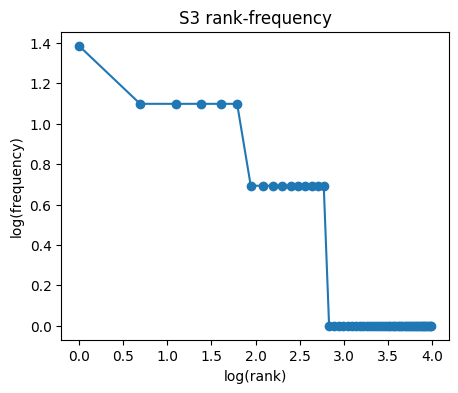

Top 5 bigrams S1: [(('the', 'server'), 3), (('when', 'i'), 3), (('i', 'use'), 3), (('use', 'mobile'), 3), (('mobile', 'hotspot'), 3)]
Top 5 bigrams S3: [(('use', 'mobile'), 3), (('mobile', 'hotspot'), 3), (('server', 'restarting'), 2), (('restarting', 'system'), 2), (('stopped', 'syncing'), 2)]


In [10]:
from collections import Counter
import math, matplotlib.pyplot as plt
from nltk import bigrams

S1_t = [proc[t]["tokens"] for t in df.Ticket_ID]
S3_t = [proc[t]["final"] for t in df.Ticket_ID]
S1 = [w for x in S1_t for w in x]
S2 = [w for t in df.Ticket_ID for w in proc[t]["tokens"] if w in set(proc[t]["final"]) or w in set(proc[t]["stops"])]
S3 = [w for x in S3_t for w in x]
S4 = [port.stem(w) for w in S3]

stats = pd.DataFrame({n: {"total": len(s), "unique": len(set(s)), "TTR": round(len(set(s))/len(s), 4)}
                      for n, s in {"S1 all": S1, "S2 no punct": S2, "S3 final": S3, "S4 porter": S4}.items()}).T
display(stats)

print("Top 10 S1:", Counter(S1).most_common(10))
print("Top 10 S3:", Counter(S3).most_common(10))

freq = sorted(Counter(S3).values(), reverse=True)
plt.figure(figsize=(5, 4))
plt.plot([math.log(i+1) for i in range(len(freq))], [math.log(f) for f in freq], "o-")
plt.xlabel("log(rank)"); plt.ylabel("log(frequency)"); plt.title("S3 rank-frequency"); plt.show()

for name, lists in [("S1", S1_t), ("S3", S3_t)]:
    print(f"Top 5 bigrams {name}:", Counter(b for x in lists for b in bigrams(x)).most_common(5))

**Observe:** Why does TTR change from S1 to S4 in your data?

Your answer:TTR rises from 0.5385 (S1) to 0.5923 (S2) and 0.7013 (S3), then dips slightly to 0.6883 (S4). Punctuation (26 tokens, "." alone 20 times) and stopwords ("the" 11 times) are repeated a lot. Removing them cuts the tokens from 156 to 77 but the unique types only from 84 to 54, so the ratio goes up. Porter then merges "open" and "opening", dropping unique types from 54 to 53, so TTR falls slightly.

## Q6. Interpretation

**(a) Why does TTR change from S1 to S4?**
TTR rises from 0.5385 (S1) to 0.5923 (S2) and 0.7013 (S3), then dips slightly to 0.6883 (S4). Punctuation (26 tokens, with "." appearing 20 times) and stopwords ("the" 11 times) are repeated a lot. Removing them cuts the token count from 156 to 77 but the unique count only from 84 to 54, so the ratio goes up. Porter then merges variants such as "open" and "opening", removing one unique type (54 to 53), so TTR falls slightly.

**(b) Where do word_tokenize() and my tokenizer differ?**
For "don't" (T04), word_tokenize gives "do" + "n't" because the Treebank-style tokenizer splits contractions into a base word and a clitic. My RegexpTokenizer pattern allows an apostrophe inside a word, so it keeps "don't" as one token. The same happens with "isn't" and "It's".

**(c) Where does stemming give an undesirable result?**
Porter stems "several" to "sever", which is a different word with a different meaning. Lancaster is worse: "unable" becomes "un" and "error" becomes "er".

**(d) Where does POS-aware lemmatization preserve meaning better?**
With the VBN/VBD tag, the lemmatizer turns "tried" into "try" and "changed" into "change", which are real words. The stemmers give "tri" and "chang", which lose readability and wouldn't match "try" or "change".